# Radar Undistortion

Please read the `README.md` file before running this tutorial.

This tutorial demonstrates how to undistort the raw radar data. This tutorial only applies to Boreas-RT sequences, which include information for beta (Doppler distortion), radar offset, and azimuth chirp type. However, the same procedure applies to Boreas data as well, where a constant offset must be subtracted.

For details, see:

Burnett, K., Schoellig, A. P., and Barfoot, T. D.  
*Do We Need to Compensate for Motion Distortion and Doppler Effects in Spinning Radar Navigation?*  
arXiv:2011.03512, 2021.  
[Paper link](https://arxiv.org/abs/2011.03512)

<details>
<summary>BibTeX</summary>

```bibtex
@misc{burnett2021needcompensatemotiondistortion,
  title={Do We Need to Compensate for Motion Distortion and Doppler Effects in Spinning Radar Navigation?},
  author={Keenan Burnett and Angela P. Schoellig and Timothy D. Barfoot},
  year={2021},
  eprint={2011.03512},
  archivePrefix={arXiv},
  primaryClass={cs.RO},
  url={https://arxiv.org/abs/2011.03512},
}

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from pyboreas import BoreasDataset
from pyboreas.utils.utils import get_inverse_tf
from scipy.ndimage import shift
from pyboreas.utils.odometry import interpolate_poses 
from pyboreas.data.metadata_splits import radar_chirp_type_upgrade_time

root = '/path/to/data/boreas/'
split = None
# AWS: Note: Free Tier SageMaker instances don't have enough storage (25 GB) for 1 sequence (100 GB)
# root = '/home/ec2-user/SageMaker/boreas/'
# split = [['boreas-2021-09-02-11-42', 163059759e6, 163059760e6-1]]

# With verbose=True, the following will print information about each sequence
bd = BoreasDataset(root, split=split, verbose=True)
# Grab the first sequence
seq = bd.sequences[0]

In [ ]:
# Double check that sequence is from Boreas-RT

if radar_chirp_type_upgrade_time < seq.radar_frames[0].timestamp:
    print("Using Boreas-RT Data!")
else:
    print("Not using Boreas-RT Data! Following tutorial cells will not run with Boreas sequences! Do not proceed!")

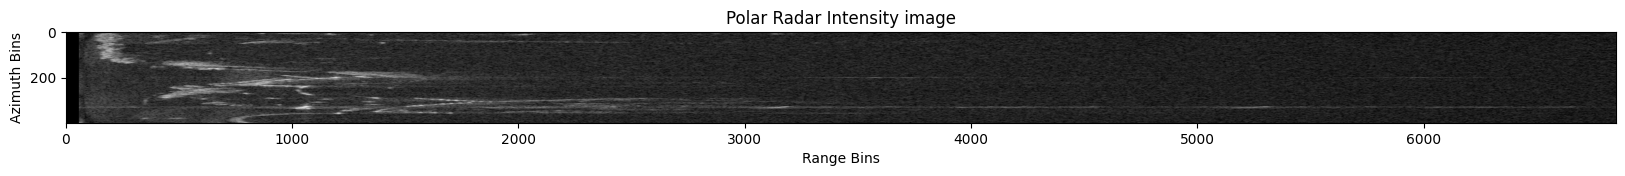

In [ ]:
# The raw radar data is contained within a polar image.
# Note that the first 2.5 meters of the radar image are zeroed out by default
# to remove noise from the vehicle itself.

rad = seq.get_radar(0)
plt.figure(figsize=(20, 100))
polar_img = plt.imshow(rad.polar, cmap="gray")
plt.title("Polar Radar Intensity image")
plt.xlabel("Range Bins")
plt.ylabel("Azimuth Bins")
plt.show()

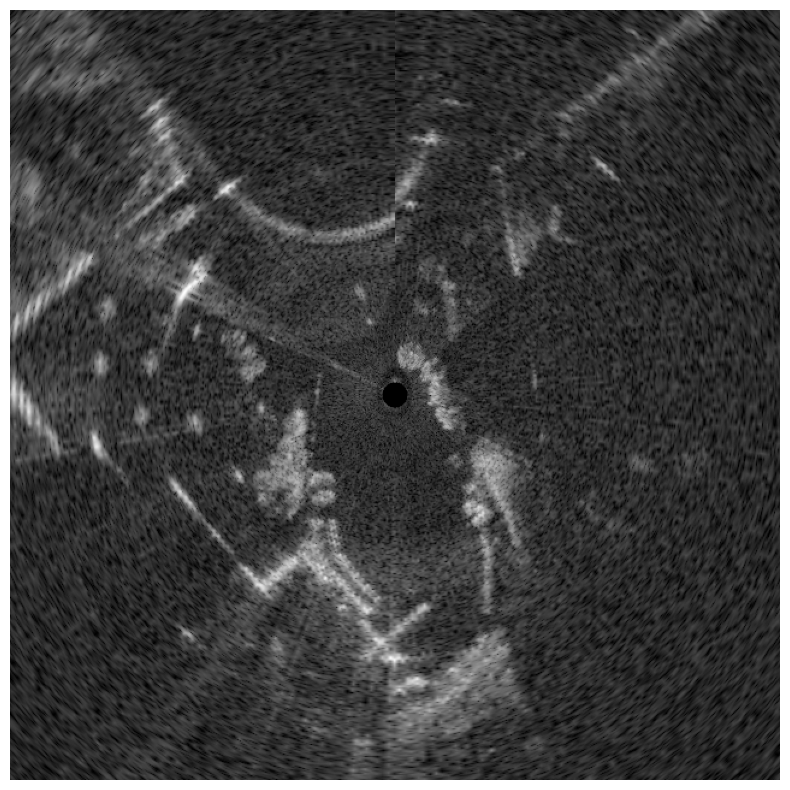

In [22]:
# Below we present the raw distorted cartesian image

rad.visualize();

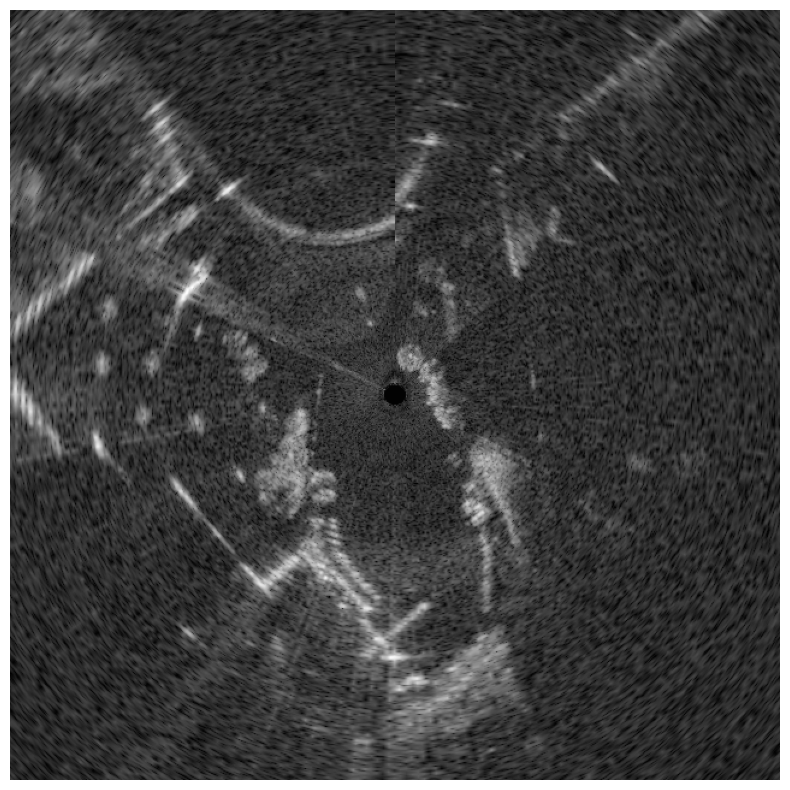

In [ ]:
# First correct each azimuth of polar image for radar offset and Doppler Distortion.
# We use the ground truth body_rate of each radar frame to obtain the radial velocity and correct for Doppler Distortion 
# where body_rate is a 6 x 1 velocity in sensor frame [v_se_in_s; w_se_in_s] (s = sensor frame, e = ENU frame).
# Note that radial velocity is in the opposite direction to the projected body_rate along the line of sight, so 
# we use v_es_in_s = -v_se_in_s.

# Constant correction offset (radar signal travels 31 cm vertically before being reflected outwards)
shifted_polar = shift(rad.polar, shift=(0, seq.calib.radar_offset / rad.resolution), order=3, mode='nearest')

# Doppler distortion correction
vx = -rad.body_rate[0]
vy = -rad.body_rate[1]
u = vx * np.cos(rad.azimuths) + vy * np.sin(rad.azimuths)
beta = seq.calib.radar_doppler_beta
delta_r_d = beta * u
chirp_sign = np.where(rad.chirp_type == 0, -1, rad.chirp_type)
doppler_shift = chirp_sign * delta_r_d / rad.resolution # need to SUBTRACT this to get real range

for idx in range(rad.polar.shape[0]):
    shifted_polar[idx] = shift(
        shifted_polar[idx],
        shift=-doppler_shift[idx], # negative to undistort
        order=3,
        mode='nearest'
    )

rad.polar = shifted_polar
rad.visualize();

In [24]:
# To correct for motion distortion, use the interpolate_poses function to get the radar pose for each azimuth.
# Using the poses and timestamps of the previous, current, and next frame, the pose of each radar azimuth can
# be obtained. The undistort_motion function uses the current frame pose (halfway through the scan) as the 
# reference frame. Each azimuth is then converted from polar to cartesian and transformed into the reference
# frame. With azimuth_upsample = 1, the cartesian image will be formed without any interpolation between
# adjacent azimuths. 

poses = [seq.radar_frames[i - 1].pose, seq.radar_frames[i].pose, seq.radar_frames[i + 1].pose] # poses are T_enu_radar
times = [seq.radar_frames[i - 1].timestamp_micro, seq.radar_frames[i].timestamp_micro, seq.radar_frames[i + 1].timestamp_micro]
query_times = rad.timestamps.flatten().tolist()
query_poses = interpolate_poses(poses, times, query_times)

cart = rad.undistort_motion(
    query_poses, 
    cart_resolution = 0.2384,
    cart_pixel_width = 640, 
    azimuth_upsample = 1
    )

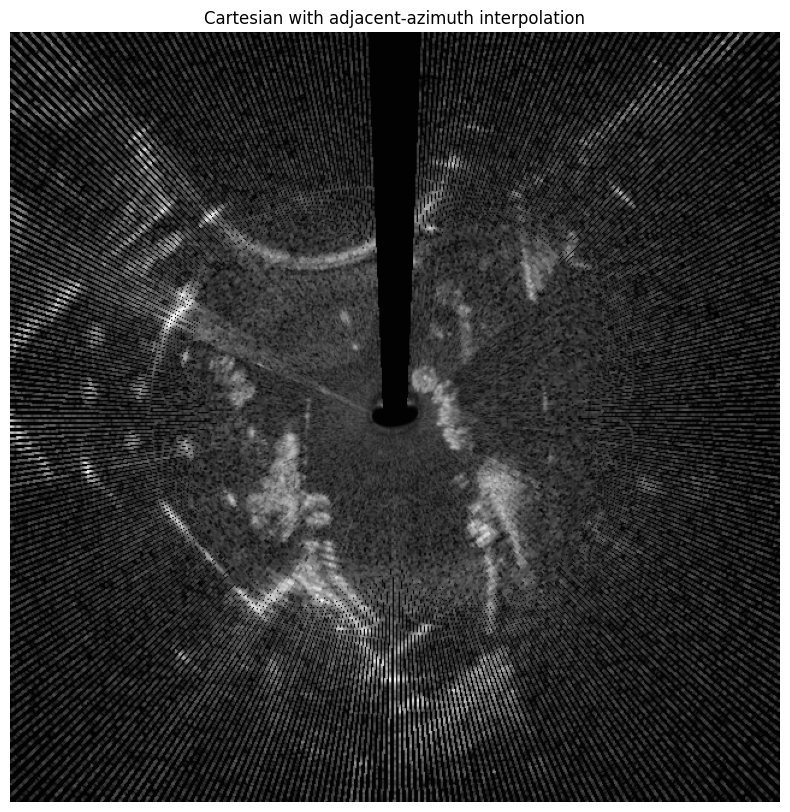

In [25]:
# The corrected cartesian image is below. Note that the black region is due to rotation
# of the vehicle during the radar frame scan

plt.figure(figsize=(10,10))
plt.imshow(cart, cmap="gray")
plt.title("Cartesian with adjacent-azimuth interpolation")
plt.axis("off")
plt.show()

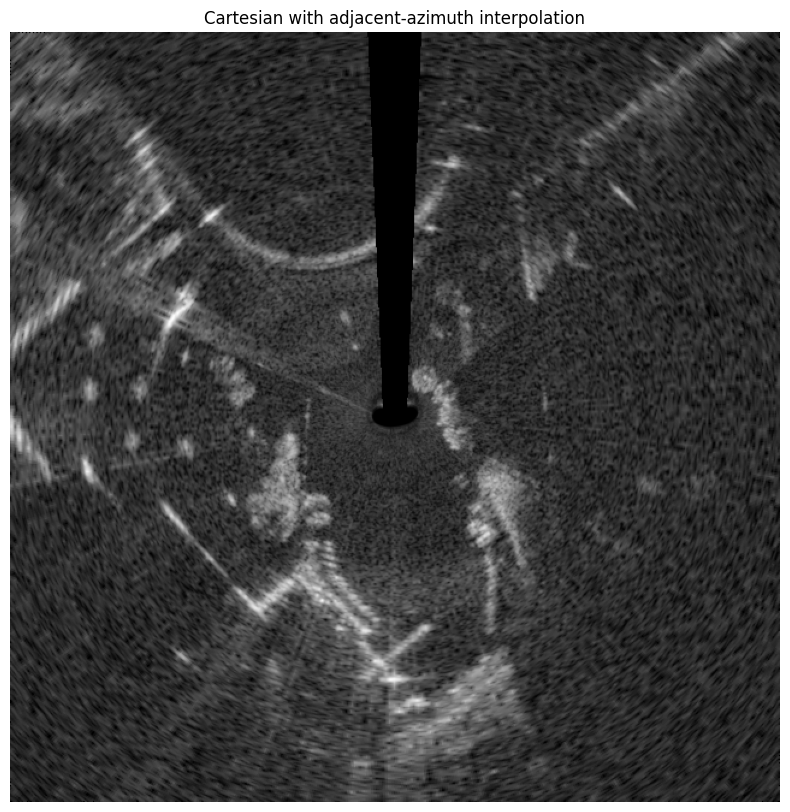

In [27]:
# We can increase azimuth_upsample to allow for interpolation

cart = rad.undistort_motion(
    query_poses, 
    cart_resolution = 0.2384,
    cart_pixel_width = 640, 
    azimuth_upsample = 3
    )

plt.figure(figsize=(10,10))
plt.imshow(cart, cmap="gray")
plt.title("Cartesian with adjacent-azimuth interpolation")
plt.axis("off")
plt.show()

In [28]:
# Do not forget to unload the radar frame

rad.unload_data()